# One single-qubit run: state, first derivative, and second derivative

This notebook presents the calculation in the order it happens:

1. run one long, explicitly driven single-qubit trajectory and inspect its measurement signal;
2. propagate the first tangent and inspect the response of the signal and AoT density;
3. propagate the second tangent and inspect the curvature;
4. compare both tangent formulations with same-noise finite differences.

The canonical implementation is in `quantum_measurement.aot_single_qubit`. Derivatives use `theta = log(gamma)` at fixed `J`. Finite differences are validation diagnostics only, not production estimators.

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from quantum_measurement.aot_single_qubit import (
    paired_derivative_validation,
    rademacher_noise,
    second_order_summary,
    simulate_ensemble,
    validate_aot_second_order_finite_difference,
)

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.grid': True,
    'font.size': 12,
})

## 1. Run one long single-qubit trajectory

We use one trajectory here so the physical signal and its derivatives can be inspected directly. The run is long enough to show sustained stochastic behavior while remaining practical to execute interactively. The same explicit noise history is retained for every finite-difference comparison below.

In [7]:
J = 1.0
g = 1.0
gamma = 4.0 * J * g
dt = 0.005
burn_in = 800
n_steps = 4000
n_trajectories = 1
seed = 20261003

noise = rademacher_noise(
    n_trajectories=n_trajectories,
    n_steps=n_steps,
    seed=seed,
)

central_first, first_history = simulate_ensemble(
    gamma=gamma,
    noise=noise,
    J=J,
    dt=dt,
    burn_in=burn_in,
    store_history=True,
)

print(f'gamma={gamma:.4f}, total time={n_steps * dt:.3f}, burn-in={burn_in * dt:.3f}')
print(f'measured time={n_steps - burn_in} steps, trajectories={n_trajectories}')
print(f'q={central_first.q[0]:.6f}, Q={central_first.Q[0]:.6f}')
print(f'max normalization error={central_first.max_norm_error:.3e}')
print(f'max tangent gauge error={central_first.max_gauge_error:.3e}')

gamma=4.0000, total time=20.000, burn-in=4.000
measured time=3200 steps, trajectories=1
q=1.640321, Q=104.980556
max normalization error=1.110e-15
max tangent gauge error=8.882e-16


## 2. The single-qubit measurement signal and AoT density

The first view is the trajectory itself. We record `z(t)`, the local AoT density `1 + z(t)^2`, and the cumulative measured average. The burn-in boundary is shown so it is clear which part contributes to `q`.

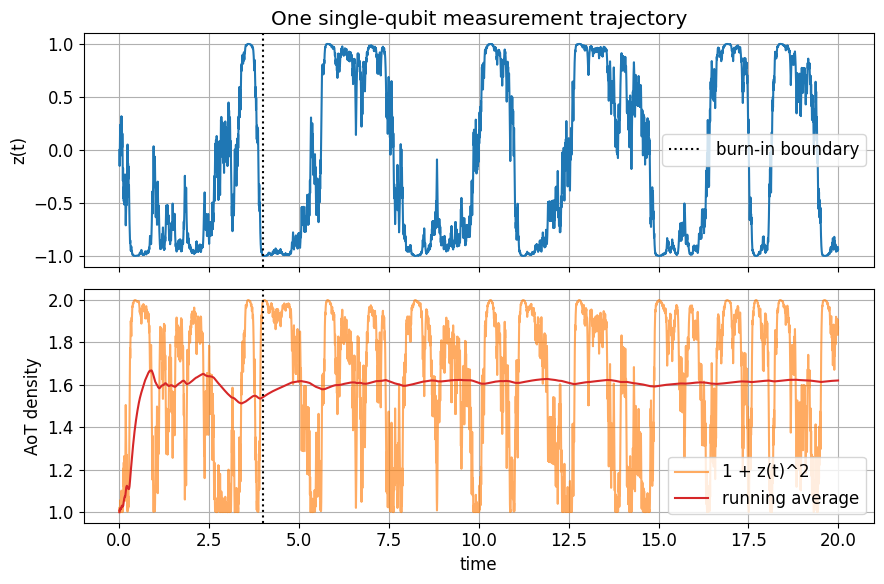

measured q from the long run = 1.640321


In [8]:
time = dt * np.arange(n_steps)
z_values = first_history['z'][0]
aot_density = 1.0 + z_values ** 2
running_q = np.cumsum(aot_density) / np.arange(1, n_steps + 1)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
axes[0].plot(time, z_values, color='tab:blue')
axes[0].axvline(burn_in * dt, color='black', linestyle=':', label='burn-in boundary')
axes[0].set_ylabel('z(t)')
axes[0].set_title('One single-qubit measurement trajectory')
axes[0].legend()

axes[1].plot(time, aot_density, color='tab:orange', alpha=0.65, label='1 + z(t)^2')
axes[1].plot(time, running_q, color='tab:red', label='running average')
axes[1].axvline(burn_in * dt, color='black', linestyle=':')
axes[1].set_xlabel('time')
axes[1].set_ylabel('AoT density')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'measured q from the long run = {central_first.q[0]:.6f}')

## 3. First derivative: tangent response of the same run

The first tangent is `u(t) = d z(t) / d theta`. For the AoT density, the corresponding instantaneous response is `2 z(t) u(t)`. We plot both before comparing the integrated derivative with a same-noise finite difference.

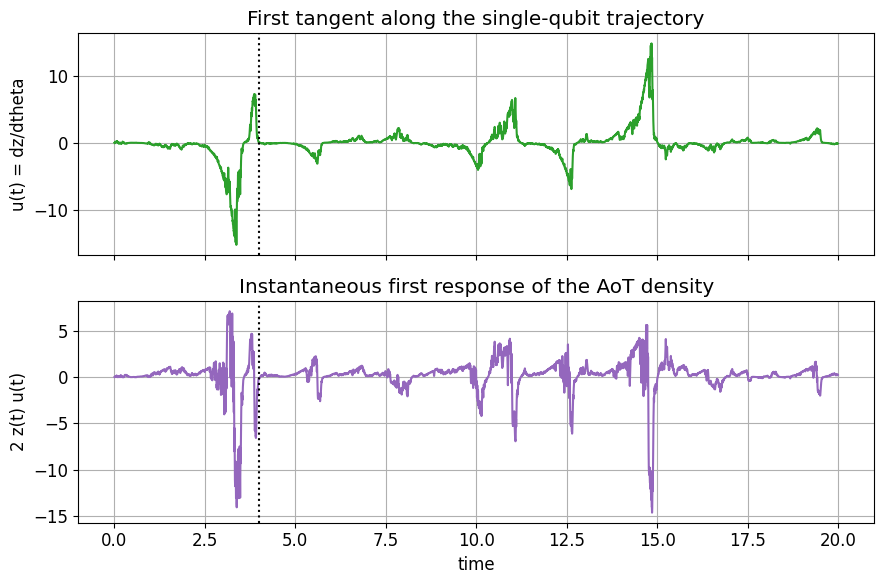

direct dq/dtheta = +0.23771794
direct dQ/dtheta = +120.19450419
h        tangent dq       FD dq           q RMS         tangent dQ      FD dQ           Q RMS
5.0e-02  +0.2377179  +0.2267720  1.095e-02  +120.1945042  +119.7074311  4.871e-01
1.0e-02  +0.2377179  +0.2373792  3.387e-04  +120.1945042  +120.1826570  1.185e-02
5.0e-03  +0.2377179  +0.2376343  8.365e-05  +120.1945042  +120.1916187  2.885e-03
1.0e-03  +0.2377179  +0.2377146  3.333e-06  +120.1945042  +120.1943898  1.144e-04


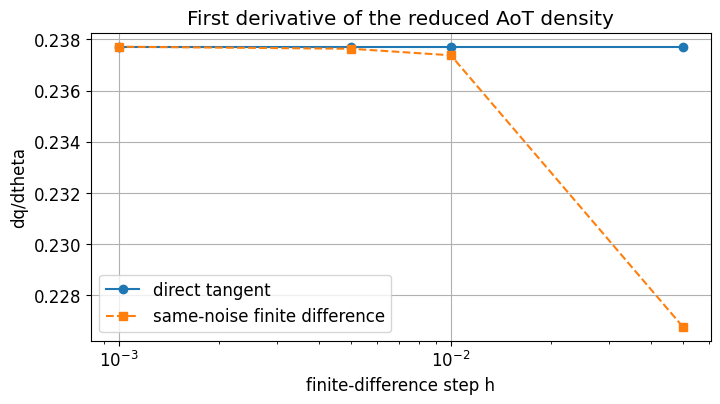

In [9]:
u_values = first_history['u'][0]
first_aot_response = 2.0 * z_values * u_values

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
axes[0].plot(time, u_values, color='tab:green')
axes[0].axvline(burn_in * dt, color='black', linestyle=':')
axes[0].set_ylabel('u(t) = dz/dtheta')
axes[0].set_title('First tangent along the single-qubit trajectory')

axes[1].plot(time, first_aot_response, color='tab:purple')
axes[1].axvline(burn_in * dt, color='black', linestyle=':')
axes[1].set_xlabel('time')
axes[1].set_ylabel('2 z(t) u(t)')
axes[1].set_title('Instantaneous first response of the AoT density')
plt.tight_layout()
plt.show()

first_h_values = [5.0e-2, 1.0e-2, 5.0e-3, 1.0e-3]
first_rows = []
for h in first_h_values:
    comparison, _ = paired_derivative_validation(
        g=g,
        h=h,
        noise=noise,
        J=J,
        dt=dt,
        burn_in=burn_in,
        central=central_first,
    )
    first_rows.append({
        'h': h,
        'tangent_q': float(np.mean(comparison.tangent_q)),
        'finite_q': float(np.mean(comparison.finite_difference_q)),
        'tangent_Q': float(np.mean(comparison.tangent_Q)),
        'finite_Q': float(np.mean(comparison.finite_difference_Q)),
        'q_rms': float(np.sqrt(np.mean(comparison.q_difference ** 2))),
        'Q_rms': float(np.sqrt(np.mean(comparison.Q_difference ** 2))),
    })

print(f'direct dq/dtheta = {central_first.chi_q[0]:+.8f}')
print(f'direct dQ/dtheta = {central_first.chi_Q[0]:+.8f}')
print('h        tangent dq       FD dq           q RMS         tangent dQ      FD dQ           Q RMS')
for row in first_rows:
    print(
        f"{row['h']:.1e}  {row['tangent_q']:+.7f}  {row['finite_q']:+.7f}  "
        f"{row['q_rms']:.3e}  {row['tangent_Q']:+.7f}  {row['finite_Q']:+.7f}  {row['Q_rms']:.3e}"
    )

first_h = np.array([row['h'] for row in first_rows])
first_tangent_q = np.array([row['tangent_q'] for row in first_rows])
first_finite_q = np.array([row['finite_q'] for row in first_rows])

fig, ax = plt.subplots()
ax.plot(first_h, first_tangent_q, marker='o', label='direct tangent')
ax.plot(first_h, first_finite_q, marker='s', linestyle='--', label='same-noise finite difference')
ax.set_xscale('log')
ax.set_xlabel('finite-difference step h')
ax.set_ylabel('dq/dtheta')
ax.set_title('First derivative of the reduced AoT density')
ax.legend()
plt.show()

## 4. Second derivative: curvature of the same run

The second tangent is `v(t) = d2 z(t) / d theta2`. The instantaneous second response of the AoT density is `2 (u(t)^2 + z(t) v(t))`. This makes the meaning of the second derivative visible before we check the integrated result against a central second difference.

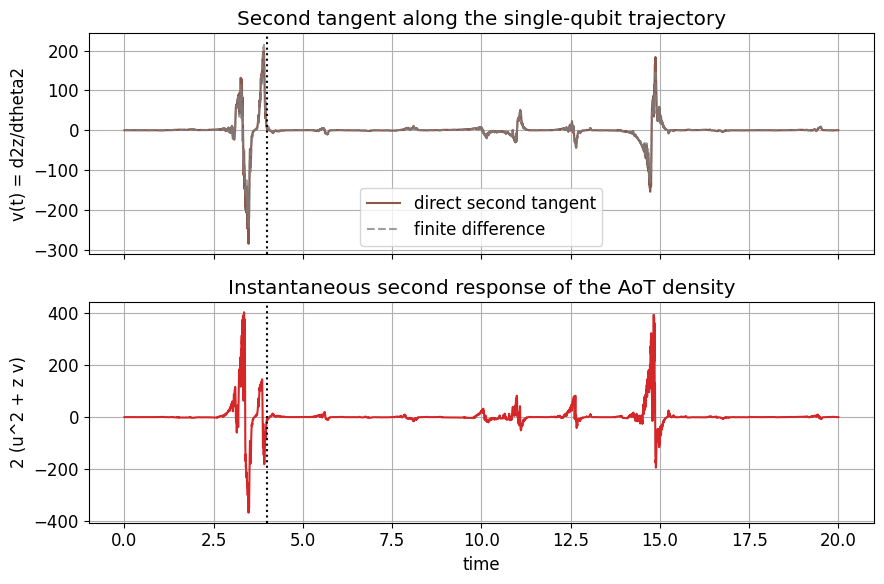

direct d2q/dtheta2 = +2.30544317
direct d2Q/dtheta2 = +282.95681514
h        tangent d2q      FD d2q          q RMS         tangent d2Q     FD d2Q          Q RMS
4.0e-02  +2.3054432  +2.0427643  2.627e-01  +282.9568151  +265.4485270  1.751e+01
2.0e-02  +2.3054432  +2.2368585  6.858e-02  +282.9568151  +278.4203955  4.536e+00
1.0e-02  +2.3054432  +2.2879559  1.749e-02  +282.9568151  +281.8029748  1.154e+00
5.0e-03  +2.3054432  +2.3010471  4.396e-03  +282.9568151  +282.6669438  2.899e-01


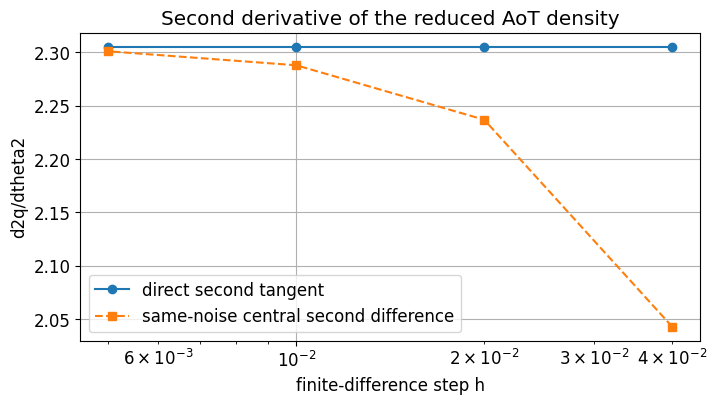

In [10]:
second_h_values = [4.0e-2, 2.0e-2, 1.0e-2, 5.0e-3]
second_rows = []
second_validation = None
for h in second_h_values:
    validation = validate_aot_second_order_finite_difference(
        gamma=gamma,
        J=J,
        dt=dt,
        n_burnin=burn_in,
        n_samples=n_steps - burn_in,
        h=h,
        noise=noise,
    )
    if second_validation is None:
        second_validation = validation
    q_difference = (
        validation.tangent.d2q_dtheta2
        - validation.finite_difference_d2q_dtheta2
    )
    Q_difference = (
        validation.tangent.d2Q_dtheta2
        - validation.finite_difference_d2Q_dtheta2
    )
    second_rows.append({
        'h': h,
        'tangent_q': float(np.mean(validation.tangent.d2q_dtheta2)),
        'finite_q': float(np.mean(validation.finite_difference_d2q_dtheta2)),
        'tangent_Q': float(np.mean(validation.tangent.d2Q_dtheta2)),
        'finite_Q': float(np.mean(validation.finite_difference_d2Q_dtheta2)),
        'q_rms': float(np.sqrt(np.mean(q_difference ** 2))),
        'Q_rms': float(np.sqrt(np.mean(Q_difference ** 2))),
    })

v_values = second_validation.history.v[0]
second_aot_response = 2.0 * (u_values ** 2 + z_values * v_values)
finite_v_values = second_validation.finite_difference_v[0]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
axes[0].plot(time, v_values, color='tab:brown', label='direct second tangent')
axes[0].plot(time, finite_v_values, color='tab:gray', linestyle='--', alpha=0.75, label='finite difference')
axes[0].axvline(burn_in * dt, color='black', linestyle=':')
axes[0].set_ylabel('v(t) = d2z/dtheta2')
axes[0].set_title('Second tangent along the single-qubit trajectory')
axes[0].legend()

axes[1].plot(time, second_aot_response, color='tab:red')
axes[1].axvline(burn_in * dt, color='black', linestyle=':')
axes[1].set_xlabel('time')
axes[1].set_ylabel('2 (u^2 + z v)')
axes[1].set_title('Instantaneous second response of the AoT density')
plt.tight_layout()
plt.show()

print(f'direct d2q/dtheta2 = {second_validation.tangent.d2q_dtheta2[0]:+.8f}')
print(f'direct d2Q/dtheta2 = {second_validation.tangent.d2Q_dtheta2[0]:+.8f}')
print('h        tangent d2q      FD d2q          q RMS         tangent d2Q     FD d2Q          Q RMS')
for row in second_rows:
    print(
        f"{row['h']:.1e}  {row['tangent_q']:+.7f}  {row['finite_q']:+.7f}  "
        f"{row['q_rms']:.3e}  {row['tangent_Q']:+.7f}  {row['finite_Q']:+.7f}  {row['Q_rms']:.3e}"
    )

second_h = np.array([row['h'] for row in second_rows])
second_tangent_q = np.array([row['tangent_q'] for row in second_rows])
second_finite_q = np.array([row['finite_q'] for row in second_rows])

fig, ax = plt.subplots()
ax.plot(second_h, second_tangent_q, marker='o', label='direct second tangent')
ax.plot(second_h, second_finite_q, marker='s', linestyle='--', label='same-noise central second difference')
ax.set_xscale('log')
ax.set_xlabel('finite-difference step h')
ax.set_ylabel('d2q/dtheta2')
ax.set_title('Second derivative of the reduced AoT density')
ax.legend()
plt.show()

## 5. Invariants and what this run demonstrates

The direct result records the normalization and tangent constraints throughout the long trajectory. The finite-difference curves should approach the tangent curves as `h` decreases. This demonstrates consistency of the differentiated single-qubit map; it is not a claim that the long-time tangent estimator is statistically efficient or production-ready.

In [11]:
summary = second_order_summary(second_validation.tangent)

for key in (
    'q_mean',
    'dq_dtheta_mean',
    'd2q_dtheta2_mean',
    'Q_mean',
    'dQ_dtheta_mean',
    'd2Q_dtheta2_mean',
    'max_norm_error',
    'max_first_constraint_error',
    'max_second_constraint_error',
    'max_first_tangent_norm',
    'max_second_tangent_norm',
):
    print(f'{key}: {summary[key]}')

q_mean: 1.6403211920947214
dq_dtheta_mean: 0.2377179359268597
d2q_dtheta2_mean: 2.305443172566571
Q_mean: 104.98055629406217
dQ_dtheta_mean: 120.19450419338119
d2Q_dtheta2_mean: 282.95681513696076
max_norm_error: 1.1102230246251565e-15
max_first_constraint_error: 8.881784197001252e-16
max_second_constraint_error: 2.1316282072803006e-14
max_first_tangent_norm: 8.205660702855218
max_second_tangent_norm: 112.11527403512652
